In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

# DATASET

In [3]:
# carichiamo il dataset stories con le feature create nel notebook2
stories = pd.read_csv("/kaggle/input/datasets/filippotenani/uniting-stories-engineer/uniting_stories_engineered.csv")

In [5]:
stories.columns

Index(['Creator name', 'Creator_gender', 'Filename', 'Social permalink',
       'Channel', 'Followers', 'Type of content', 'Post creation date', 'mese',
       'Weekend/Settimanale', 'Post creation time', 'fascia_oraria',
       'Post caption', 'Reach', 'Likes', 'Comments', 'Total clicks',
       'Brand name', 'Industry', 'Local', 'Brand_SM', 'media_duration_sec',
       'face_frame_ratio', 'faccia', 'first_face_position_ratio',
       'motion_level', 'saturation', 'luminance', 'contrast', 'sharpness',
       'color_complexity', 'cognitive_overload', 'flashiness', 'PERC_REACHED',
       'CTR'],
      dtype='object')

# EXPLORATORY DATA ANALYSIS

The goal of this section is to explore the dataset to understand how the various columns are distributed, and we also want to understand which columns are most correlated with the targets and therefore more relevant to keep for the models.

For stories we use click_through_rate (CTR) as the main target.

## CREATOR GENDER

In [ ]:
# barplot
stories["Creator_gender"].value_counts(normalize=True).plot(kind="bar")
plt.xlabel("Creator_gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Female creators are the most present in the dataset, followed by male creators. Groups are the least present

In [ ]:
# boxplot di Creator_gender vs target
threshold = stories["CTR"].quantile(0.99) # togliamo gli outlier più estremi altrimenti risulta difficile vedere questo grafico
stories[stories["CTR"] < threshold].boxplot(column="CTR", by="Creator_gender", figsize=(10, 6))
plt.title("CTR per genere")
plt.suptitle("")
plt.xlabel("Creator_gender")
plt.ylabel("CTR")
plt.tight_layout()
plt.show()

No major differences are noticed in the target distributions (click through rate) across the various groups. Medians and variances are fairly similar. Groups seem to have slightly greater variability.

## FOLLOWERS

In [ ]:
# histogram
stories["Followers"].plot(kind="hist", bins=80, edgecolor='black', alpha=0.8)
plt.title("Distribuzione dei Followers", fontsize=16)
plt.xlabel("Numero di Followers", fontsize=12)
plt.ylabel("Frequenza", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
stories["Followers"].describe()

75% of observations refer to creators with less than 700000 followers, 50% are within 300000 followers

In [ ]:
# istogrammi follower per Creator_gender
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, sharex=True)
for ax, genere in zip(axes, ["f", "m", "o"]):
    stories[stories["Creator_gender"] == genere]["Followers"].plot(
        kind="hist", bins=80, edgecolor="black", alpha=0.8, ax=ax
    )
    ax.set_title(f"Followers - {genere}", fontsize=14)
    ax.set_xlabel("Numero di Followers", fontsize=11)

axes[0].set_ylabel("Frequenza", fontsize=11)
plt.tight_layout()
plt.show()

For males and females the distribution of followers is roughly the same, with females showing a higher peak at low follower counts. This means that in the dataset there are several female creators with a not high number of followers. Males instead are distributed in a slightly more uniform manner (with less pronounced peaks)

In [ ]:
# scatterplot followers vs target
fig, ax = plt.subplots(figsize=(10, 6))
stories.plot(kind="scatter", x="Followers", y="CTR", alpha=0.4, ax=ax)

m, b = np.polyfit(stories["Followers"], stories["CTR"], 1)
ax.plot(stories["Followers"], m * stories["Followers"] + b, color="red")

corr = stories["Followers"].corr(stories["CTR"])
ax.set_title(f"Correlation: {corr:.3f}")
plt.tight_layout()
plt.show()

The correlation between CTR and followers is negative but almost zero. This flattening is expected, since CTR neutralizes the creator's size from the start by placing reach at the denominator. However, the slight negative trend confirms a well-known marketing phenomenon: smaller creators' communities are proportionally much more interactive and loyal.

## TYPE OF CONTENT

In [ ]:
stories["Type of content"].value_counts()

This dataset contains only instagram stories, which represent 2/3 of all rows of the complete dataset (the one that also includes tiktok/instagram posts).

## POST CREATION DATE / MESE

To visualize post_creation_date we use the variable mese that we created specifically earlier.

In [ ]:
# barplot
stories["mese"].value_counts(normalize=True).plot(kind="bar")
plt.xlabel("mese")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

We see that in May, June, July and in autumn the largest quantity of stories is published. Contrary to what we expected, the winter months (which therefore include Christmas and New Year's), the Easter period (March, April) and August are the months with the fewest posts overall. This is nearly identical to what we observed in the reels dataset.

In [ ]:
# boxplot vs target
threshold = stories["CTR"].quantile(0.99) # togliamo gli outlier più estremi altrimenti risulta difficile vedere questo grafico
stories[stories["CTR"] < threshold].boxplot(column="CTR", by="mese", figsize=(10, 6))
plt.xlabel("mese")
plt.ylabel("CTR")
plt.tight_layout()
plt.show()

Regarding CTR medians, May, September, April and December record slightly better values compared to other months. What makes the real difference are the exceptional performances of individual contents: November, September and May clearly dominate in number and height of maximum peaks. On the contrary, February marks the weakest median, while August confirms itself as the flattest month overall, characterized by the most compressed distribution and the total absence of relevant outliers.

Comparing this chart with the previous one, we notice that the high publication in May and autumn is rewarded generating maximum CTR peaks, while the drastic drop in posts in August is consistent with its poor performance. April and December are surprising instead: despite the very few published contents, they maintain click medians among the highest of the year, probably related to Christmas and Easter content.

## WEEKEND

In [ ]:
# barplot
stories["Weekend/Settimanale"].value_counts(normalize=True).plot(kind="bar")
plt.xlabel("Weekend/Settimanale")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

We see that 65% of posts are on weekdays, 35% are on the weekend (in which we included Friday because we consider Friday evening as the start of the weekend).

In [ ]:
# boxplot vs target
threshold = stories["CTR"].quantile(0.99) # togliamo gli outlier più estremi altrimenti risulta difficile vedere questo grafico
stories[stories["CTR"] < threshold].boxplot(column="CTR", by="Weekend/Settimanale", figsize=(10, 6))
plt.xlabel("Weekend/Settimanale")
plt.ylabel("CTR")
plt.tight_layout()
plt.show()

Surprisingly, the engagement rate is practically identical between weekdays and weekends. We noticed the same thing in the reels dataset.

## POST CREATION TIME / FASCIA ORARIA

To visualize post_creation_time we use the variable fascia_oraria that we created specifically earlier.

In [ ]:
# barplot
stories["fascia_oraria"].value_counts(normalize=True).plot(kind="bar")
plt.xlabel("fascia_oraria")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Most stories (35%) are published at lunchtime. The afternoon also sees a significant amount of publications (25%) and also the dinner hours a bit (almost 15%). Also, unlike reels which did not record any publications at nighttime, stories see more than 10% of publications in this very time slot.

In [ ]:
# boxplot vs target
threshold = stories["CTR"].quantile(0.99) # togliamo gli outlier più estremi altrimenti risulta difficile vedere questo grafico
stories[stories["CTR"] < threshold].boxplot(column="CTR", by="fascia_oraria", figsize=(10, 6))
plt.xlabel("fascia_oraria")
plt.ylabel("CTR")
plt.tight_layout()
plt.show()

## REACH, TOTAL CLICKS

In [ ]:
# histograms
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

stories["Reach"].plot(kind="hist", bins=80, edgecolor='black', alpha=0.8, ax=axes[0])
axes[0].set_xlabel("Reach", fontsize=12)
axes[0].set_ylabel("Frequenza", fontsize=12)

stories["Total clicks"].plot(kind="hist", bins=80, edgecolor='black', alpha=0.8, ax=axes[1])
axes[1].set_xlabel("Total Clicks", fontsize=12)

plt.tight_layout()
plt.show()

In stories the maximum reach tops out at around 800k accounts. Just like in reels, the steep drop of total clicks relative to coverage confirms a strong difficulty of the audience toward any active interaction.

We do not visualize how these variables vary with respect to the target, because they themselves compose the target.

## BRAND NAME

In [ ]:
# barplot
fig, axes = plt.subplots(1, figsize=(18, 6))
stories["Brand name"].value_counts(normalize=True).plot(kind="bar")
plt.xlabel("Brand name")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

The most present brands are Vileda, Iliad, Decathlon and Amazon. Interesting how Vileda is clearly the most present brand in the dataset (14%), probably also due to the majority of female profiles present (even though female creators are not that much more numerous than males).

In [ ]:
# boxplot vs target
threshold = stories["CTR"].quantile(0.99) # togliamo gli outlier più estremi altrimenti risulta difficile vedere questo grafico
stories[stories["CTR"] < threshold].boxplot(column="CTR", by="Brand name", figsize=(18, 6))
plt.xlabel("Brand name")
plt.ylabel("CTR")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

As noticed in the reels dataset, also in the case of stories we see that the most present brands are not those that generate the highest CTR, in fact their CTR is quite low, probably because they sponsor their products to a wider audience without targeting a specific niche.

Persol and Santa Rosa are by far the brands that generate the highest CTR in stories, but their absolute presence in the dataset is very low, in particular Persol is the least present brand. This confirms the hypothesis that targeting a specific niche is more efficient if the goal is to maximize CTR.

## INDUSTRY

In [ ]:
# barplot
stories["Industry"].value_counts(normalize=True).plot(kind="bar")
plt.xlabel("Industry")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

The most present industry is retail (as also observed in reels), but in the case of stories the other 5 industries do not all have the same frequency as happens in reels, but follow a clear decreasing trend declining progressively.

In [ ]:
# boxplot vs target
threshold = stories["CTR"].quantile(0.99) # togliamo gli outlier più estremi altrimenti risulta difficile vedere questo grafico
stories[stories["CTR"] < threshold].boxplot(column="CTR", by="Industry", figsize=(10, 6))
plt.xlabel("Industry")
plt.ylabel("CTR")
plt.tight_layout()
plt.show()

We notice that the services industry is the one with the highest CTR median overall, while lifestyle has the lowest median and this is very interesting since in reels lifestyle is the industry that generates the highest engagement.

## LOCAL

In [ ]:
# barplot
stories["Local"].value_counts(normalize=True).plot(kind="bar")
plt.xlabel("Local")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

As for reels, also for stories more than 60% of sponsorships are done by non-local brands.

In [ ]:
# boxplot vs target
threshold = stories["CTR"].quantile(0.99) # togliamo gli outlier più estremi altrimenti risulta difficile vedere questo grafico
stories[stories["CTR"] < threshold].boxplot(column="CTR", by="Local", figsize=(10, 6))
plt.xlabel("Local")
plt.ylabel("CTR")
plt.tight_layout()
plt.show()

Engagement is practically the same between local and non-local brands, non-local brands have a slightly higher median probably because they are more famous and recognized international brands.

## BRAND SM

In [ ]:
# histogram
# ci sono quasi tutti valori bassi tranne pochissimi outlier estremi che rendono difficile vedere la scala per valori bassi
# so we plot two charts, one with outliers to see them too and one without to better see the low values
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

stories["Brand_SM"].plot(kind="hist", bins=80, edgecolor='black', alpha=0.8, ax=axes[0])
axes[0].set_xlabel("Brand_SM", fontsize=12)
axes[0].set_ylabel("Frequenza", fontsize=12)

stories["Brand_SM"].plot(kind="hist", bins=80, edgecolor='black', alpha=0.8, ax=axes[1])
axes[1].set_xlabel("Brand_SM", fontsize=12)
axes[1].set_ylabel("Frequenza", fontsize=12)
axes[1].set_xlim(0, 2_000_000)

plt.tight_layout()
plt.show()

The vast majority of brands are concentrated below 500,000 followers, while rare giants above 30 million create an asymmetry that distorts the perception of the dataset. This clear gap confirms that collaborations mainly occur with small-to-medium sized entities in terms of followers.

Despite Amazon doing many sponsorships, its follower count is 456k so according to this metric it does not fall among the large brands.

In [ ]:
# scatterplot vs target
fig, ax = plt.subplots(figsize=(10, 6))
stories.plot(kind="scatter", x="Brand_SM", y="CTR", alpha=0.4, ax=ax)

m, b = np.polyfit(stories["Brand_SM"], stories["CTR"], 1)
ax.plot(stories["Brand_SM"], m * stories["Brand_SM"] + b, color="red")

corr = stories["Brand_SM"].corr(stories["CTR"])
ax.set_title(f"Correlation: {corr:.3f}")
plt.tight_layout()
plt.show()

Contrary to what happens in reels where the brand's follower count leads to higher engagement, in stories the correlation is negative and close to zero, this is very curious, maybe the predictive models will explain more about this.

## MEDIA DURATION SEC

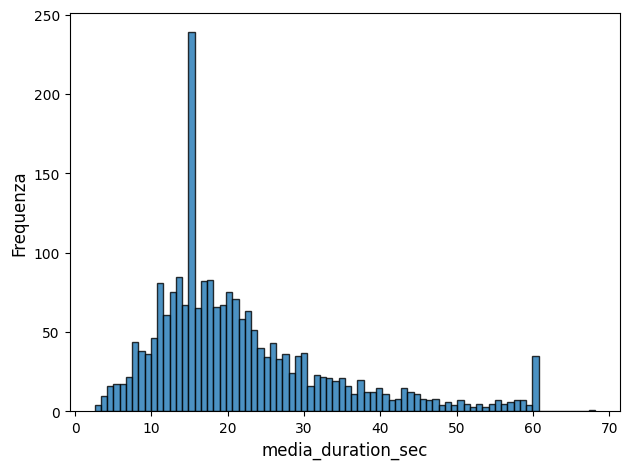

In [5]:
# histogram
stories["media_duration_sec"].plot(kind="hist", bins=80, edgecolor='black', alpha=0.8)
plt.xlabel("media_duration_sec", fontsize=12)
plt.ylabel("Frequenza", fontsize=12)
plt.tight_layout()
plt.show()

Regarding stories, the content is massively concentrated at the 10-20 second threshold, which turns out to be the most frequent format in the analyzed sample. The presence of clips drops drastically beyond 30 seconds, confirming the extremely short and fragmented nature of this type of content. Interesting is the isolated peak at 60 seconds, due to the fact that stories have a maximum duration of 60 seconds, so a fair amount of creators record stories up to the allowed time limit (there is also a single observation of 68 seconds, we don't know if it's an error).

In [10]:
stories[stories["media_duration_sec"] > 67]

,Creator name,Creator_gender,Filename,Social permalink,Channel,Followers,Type of content,Post creation date,mese,Weekend/Settimanale,Post creation time,fascia_oraria,Post caption,Reach,Likes,Comments,Total clicks,Brand name,Industry,Local,Brand_SM,media_duration_sec,face_frame_ratio,faccia,first_face_position_ratio,motion_level,saturation,luminance,contrast,sharpness,color_complexity,cognitive_overload,flashiness,PERC_REACHED,CTR
2229,Casa Abis,o,101_457_3427,NaN,instagram.com/casa.abis,658698,INSTAGRAM_STORY,2024-06-13,giugno,settimanale,00:00:00,notte,NaN,42210,NaN,NaN,7.0,AMAZON,Retail,0,456000,68.1,0.914286,1,0.0,0.787894,0.442776,116.056956,52.148705,25.395213,0.640893,1.23067,1.622563,0.064081,0.000166


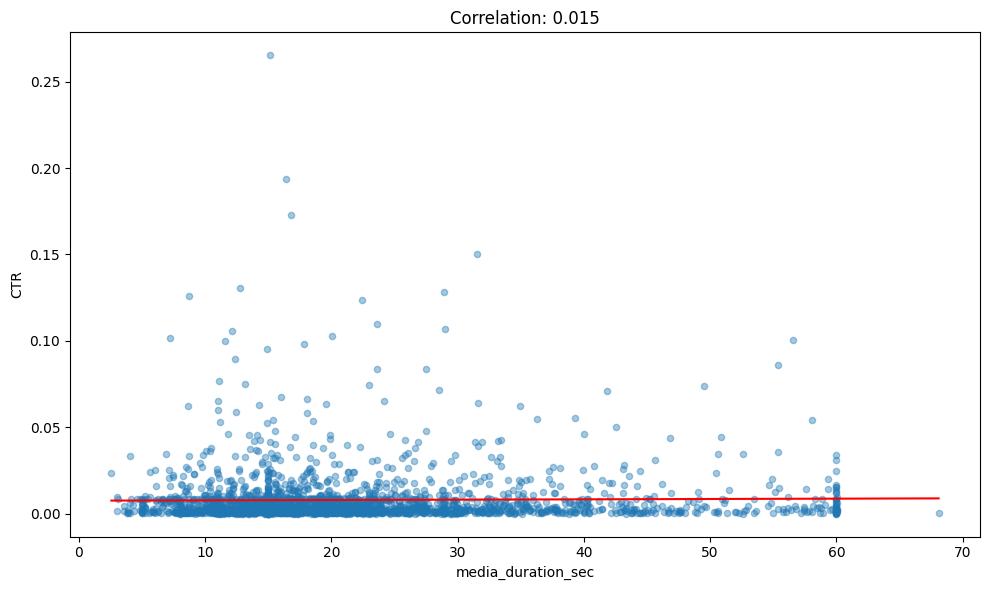

In [17]:
# scatterplot vs target
fig, ax = plt.subplots(figsize=(10, 6))
stories.plot(kind="scatter", x="media_duration_sec", y="CTR", alpha=0.4, ax=ax)

m, b = np.polyfit(stories["media_duration_sec"], stories["CTR"], 1)
ax.plot(stories["media_duration_sec"], m * stories["media_duration_sec"] + b, color="red")

corr = stories["media_duration_sec"].corr(stories["CTR"])
ax.set_title(f"Correlation: {corr:.3f}")
plt.tight_layout()
plt.show()

The duration of a story is positively correlated with the video's own CTR, but the correlation is very low, almost close to zero.

## FACE FRAME RATIO

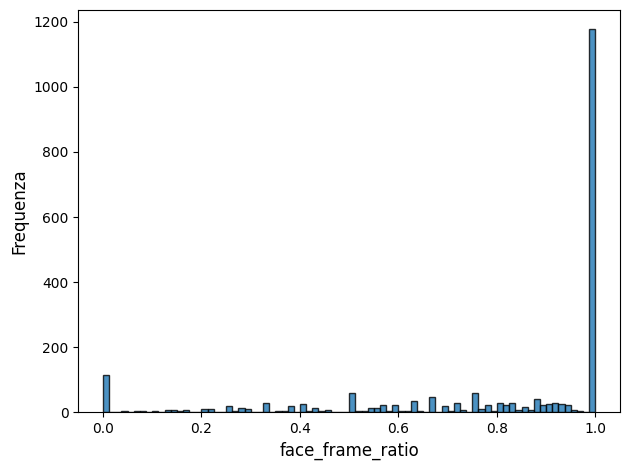

In [18]:
# histogram
stories["face_frame_ratio"].plot(kind="hist", bins=80, edgecolor='black', alpha=0.8)
plt.xlabel("face_frame_ratio", fontsize=12)
plt.ylabel("Frequenza", fontsize=12)
plt.tight_layout()
plt.show()

We notice that practically all stories show a face, this is also true for reels, but in stories it's even more pronounced, because stories simulate a direct and personal communication, almost a video call, where the absence of a face would seem unnatural. Here too in stories, as in reels, there is a small peak at 0 meaning videos without a face.

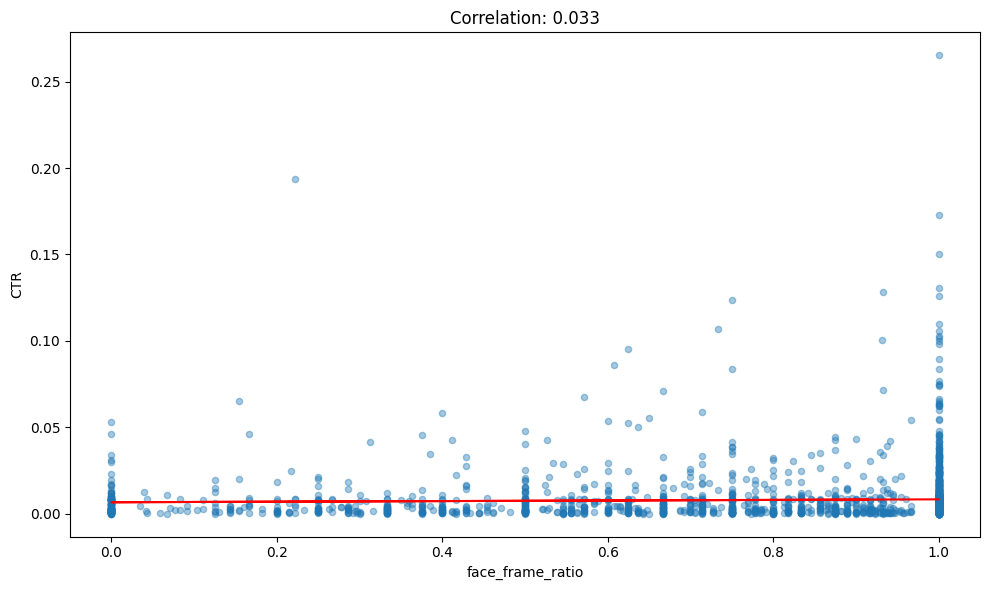

In [19]:
# scatterplot vs target
fig, ax = plt.subplots(figsize=(10, 6))
stories.plot(kind="scatter", x="face_frame_ratio", y="CTR", alpha=0.4, ax=ax)

m, b = np.polyfit(stories["face_frame_ratio"], stories["CTR"], 1)
ax.plot(stories["face_frame_ratio"], m * stories["face_frame_ratio"] + b, color="red")

corr = stories["face_frame_ratio"].corr(stories["CTR"])
ax.set_title(f"Correlation: {corr:.3f}")
plt.tight_layout()
plt.show()

We can nee that the correlation is positive but basically flat, so showing the face for longer during the video has a negligeable impact on CTR.

## FACE

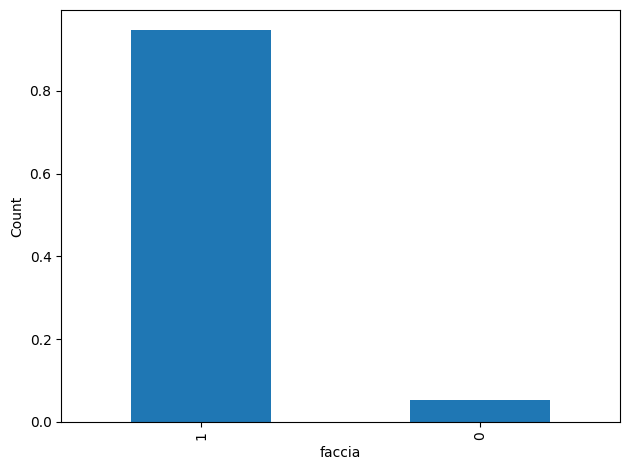

In [20]:
# barplot
stories["faccia"].value_counts(normalize=True).plot(kind="bar")
plt.xlabel("faccia")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [21]:
stories["faccia"].value_counts(normalize=True)

faccia
1    0.947982
0    0.052018
Name: proportion, dtype: float64

We can observe that 95% of reels have a face in them.

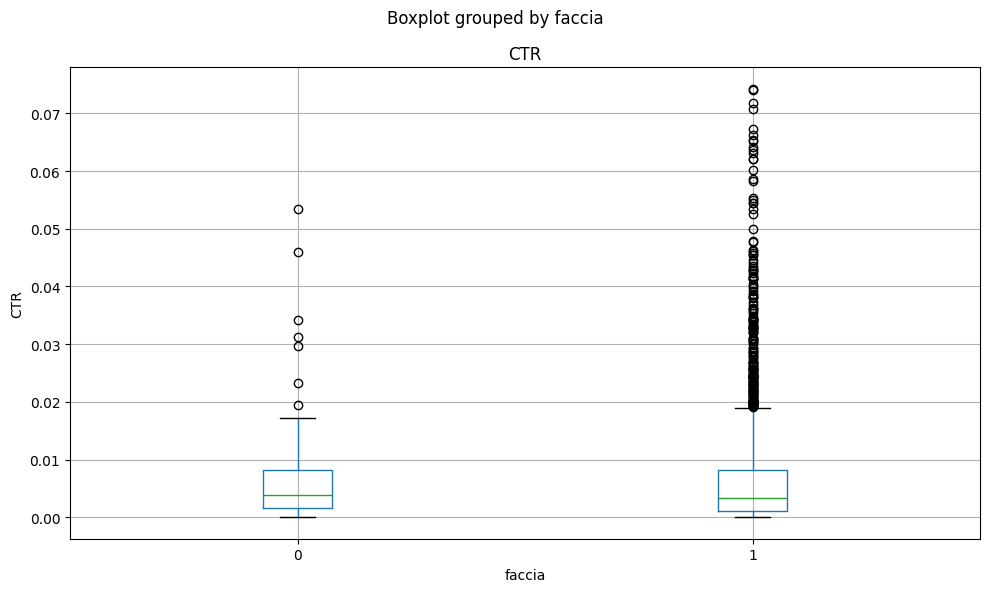

In [23]:
# boxplot vs target
threshold = stories["CTR"].quantile(0.99) # togliamo gli outlier più estremi altrimenti risulta difficile vedere questo grafico
stories[stories["CTR"] < threshold].boxplot(column="CTR", by="faccia", figsize=(10, 6))
plt.xlabel("faccia")
plt.ylabel("CTR")
plt.tight_layout()
plt.show()

Although the median engagement values are similar between the two groups, stories with a face demonstrate a clearly superior virality potential, populating the upper part of the chart with numerous high-performance outliers.

## FIRST FACE POSITION RATIO

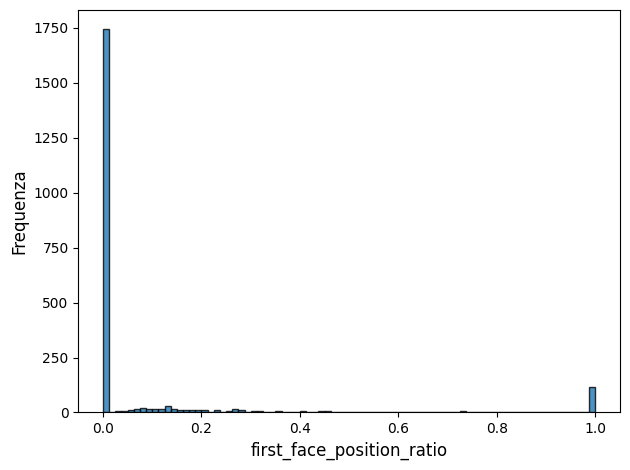

In [24]:
# histogram
stories["first_face_position_ratio"].plot(kind="hist", bins=80, edgecolor='black', alpha=0.8)
plt.xlabel("first_face_position_ratio", fontsize=12)
plt.ylabel("Frequenza", fontsize=12)
plt.tight_layout()
plt.show()

In practically all stories the face appears exactly at the beginning, in the first frame. A small peak occurs for first_face_position_ratio=1 which is the value we use as a proxy to indicate that the video has no face.

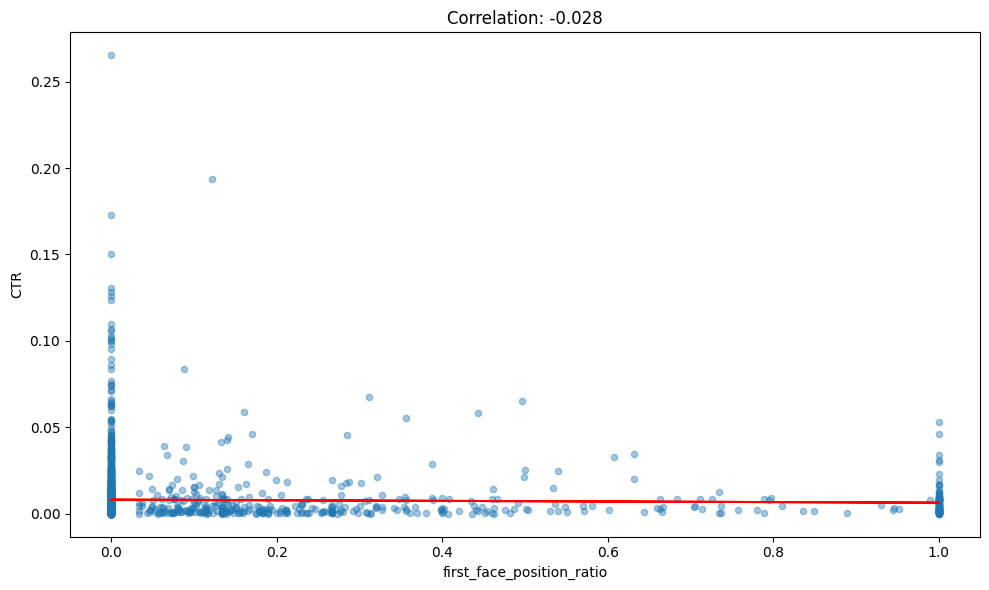

In [25]:
# scatterplot vs target
fig, ax = plt.subplots(figsize=(10, 6))
stories.plot(kind="scatter", x="first_face_position_ratio", y="CTR", alpha=0.4, ax=ax)

m, b = np.polyfit(stories["first_face_position_ratio"], stories["CTR"], 1)
ax.plot(stories["first_face_position_ratio"], m * stories["first_face_position_ratio"] + b, color="red")

corr = stories["first_face_position_ratio"].corr(stories["CTR"])
ax.set_title(f"Correlation: {corr:.3f}")
plt.tight_layout()
plt.show()

The correlation between first_face_position_ratio and CTR is practically flat, meaning that the frame in which the face is shown does not have a strong impact on CTR.

## VIDEO METRICS

Let's now analyze the features representing the video metrics:

'motion_level', 'saturation', 'luminance', 'contrast', 'sharpness', 'color_complexity'

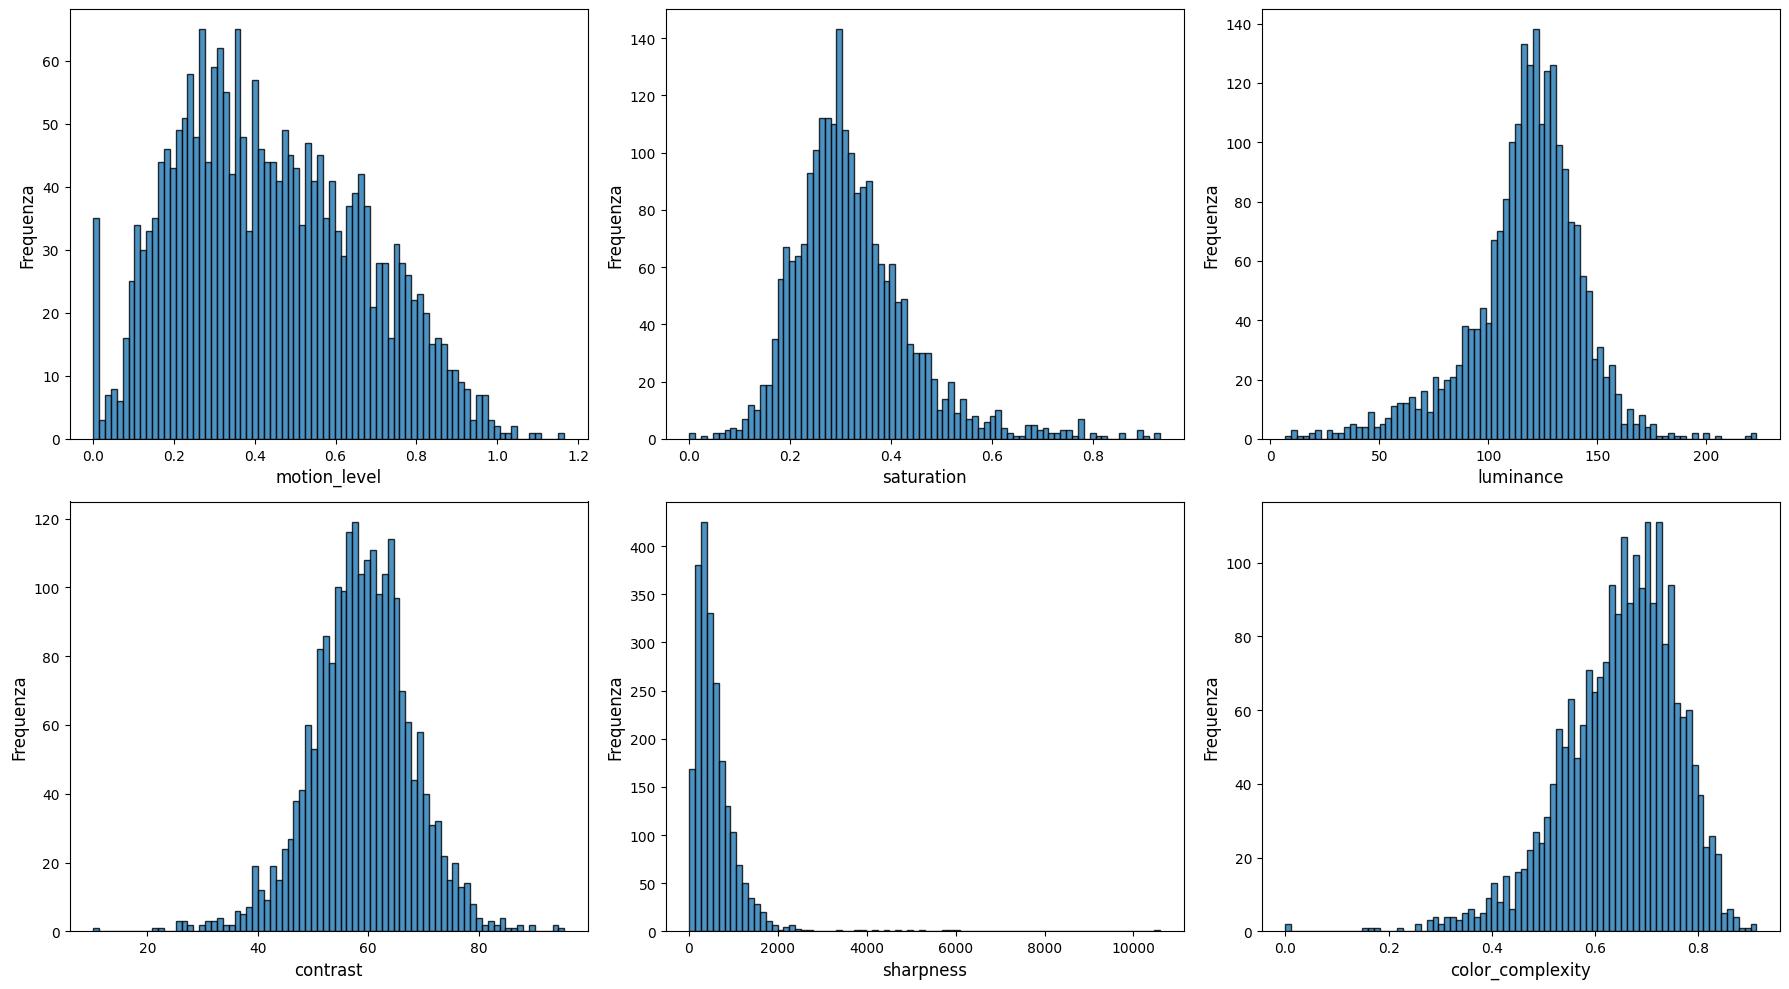

In [5]:
# histogram
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, ['motion_level', 'saturation', 'luminance', 'contrast', 'sharpness', 'color_complexity']):
    stories[col].plot(kind="hist", bins=80, edgecolor='black', alpha=0.8, ax=ax)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel("Frequenza", fontsize=12)

plt.tight_layout()
plt.show()

Saturation, luminance and contrast show normal and well-centered distributions, while sharpness is generally low. Color_complexity is at very high values, indicating chromatically rich scenes.

The main difference compared to reels is noticed in motion_level which in reels is at very high values, while in Stories the distribution is noticeably squashed toward low values, indicating a greater stillness of the content.

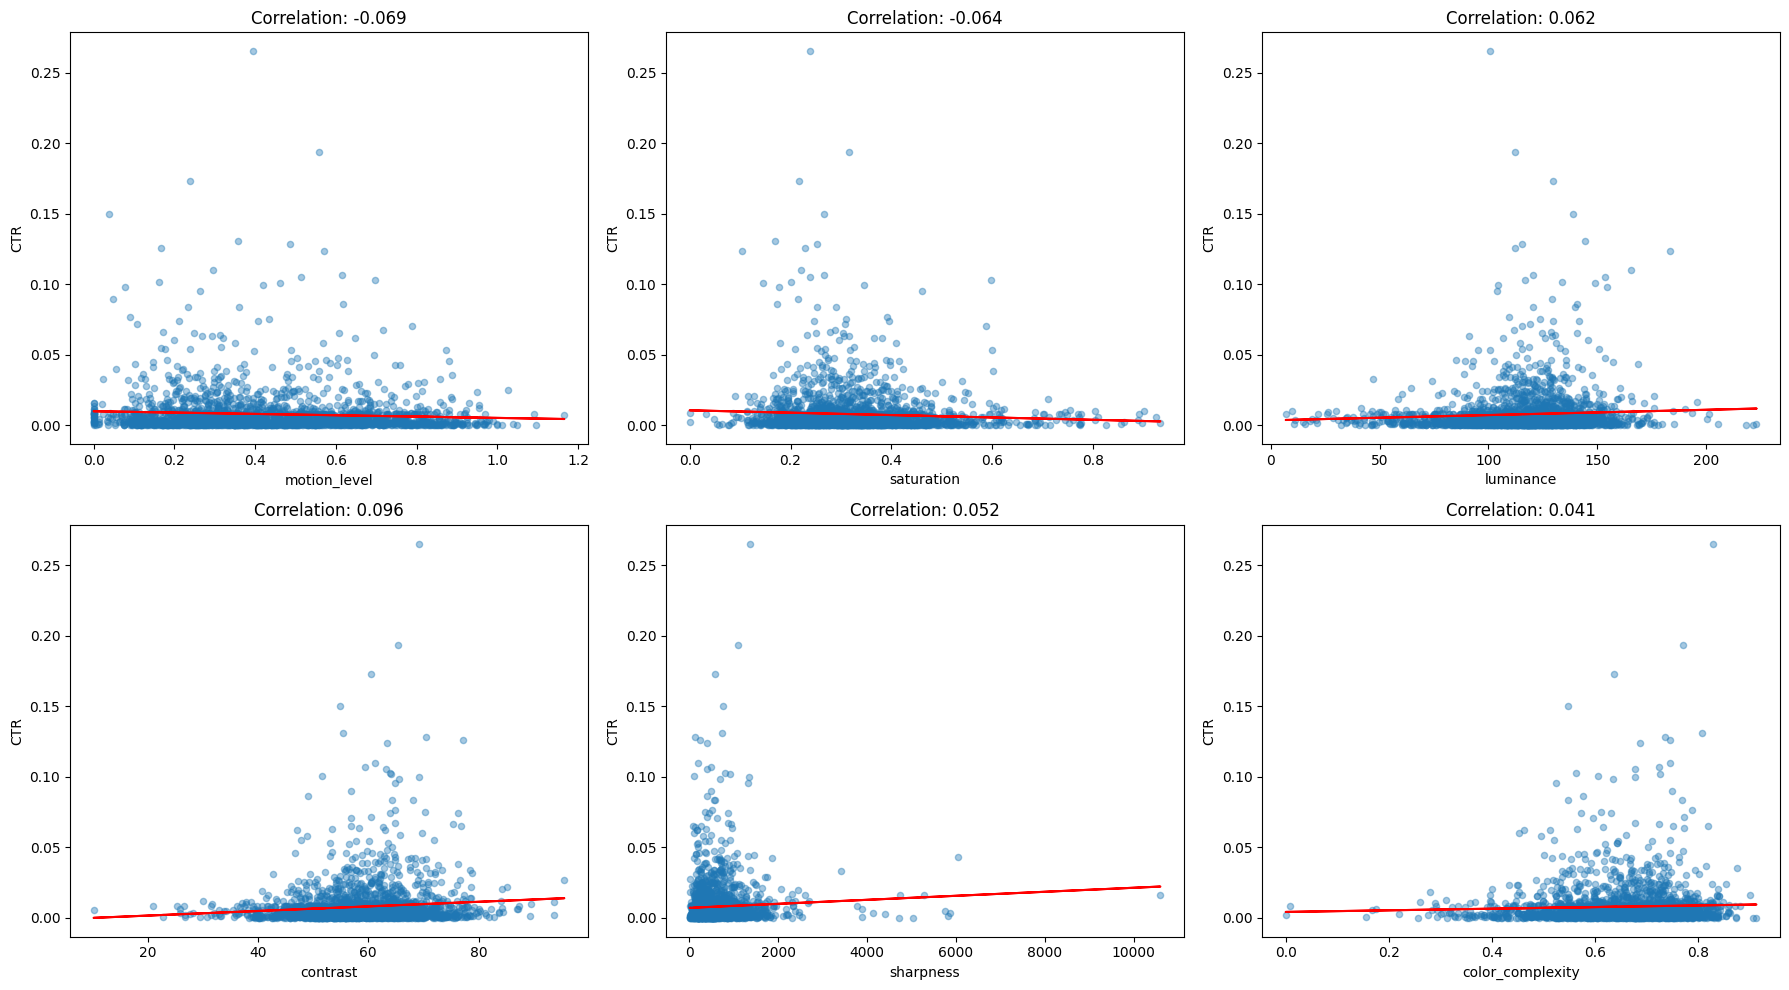

In [6]:
# scatterplot vs target
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, ['motion_level', 'saturation', 'luminance', 'contrast', 'sharpness', 'color_complexity']):
    stories.plot(kind="scatter", x=col, y="CTR", alpha=0.4, ax=ax)
    m, b = np.polyfit(stories[col], stories["CTR"], 1)
    ax.plot(stories[col], m * stories[col] + b, color="red")
    corr = stories[col].corr(stories["CTR"])
    ax.set_title(f"Correlation: {corr:.3f}")

plt.tight_layout()
plt.show()

Motion_level and saturation are the only two variables negatively correlated with engagement rate, while the other four are positively correlated. In all six cases however the correlation is extremely close to zero, essentially indicating that these variables are uncorrelated with engagement.

It would not even make sense to do a PCA on these variables, because first of all we would get PCs that are very hard to interpret (they would be combinations of video metrics) and above all they would also be uncorrelated with the target since they are a linear combination of all variables uncorrelated with the target (we tried and indeed that's what happens).

In [4]:
stories.columns

Index(['Creator name', 'Creator_gender', 'Filename', 'Social permalink',
       'Channel', 'Followers', 'Type of content', 'Post creation date', 'mese',
       'Weekend/Settimanale', 'Post creation time', 'fascia_oraria',
       'Post caption', 'Reach', 'Likes', 'Comments', 'Total clicks',
       'Brand name', 'Industry', 'Local', 'Brand_SM', 'media_duration_sec',
       'face_frame_ratio', 'faccia', 'first_face_position_ratio',
       'motion_level', 'saturation', 'luminance', 'contrast', 'sharpness',
       'color_complexity', 'cognitive_overload', 'flashiness', 'PERC_REACHED',
       'CTR'],
      dtype='object')